## Семинар: "Методы оптимизации"

In [1]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [2]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts, 7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0')
            ax.set_ylabel('w1')
            ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))

        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0, 0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:, 0], self.y,
                         c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:, 1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5,
                              cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D(
                [], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1, 0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(
                self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(
                data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(
            0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

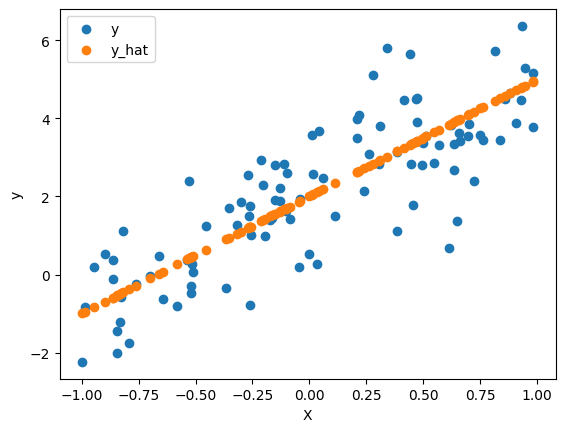

In [3]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:, 0], loss_animator.y, label='y')
plt.scatter(loss_animator.X[:, 0], y_hat, label='y_hat')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

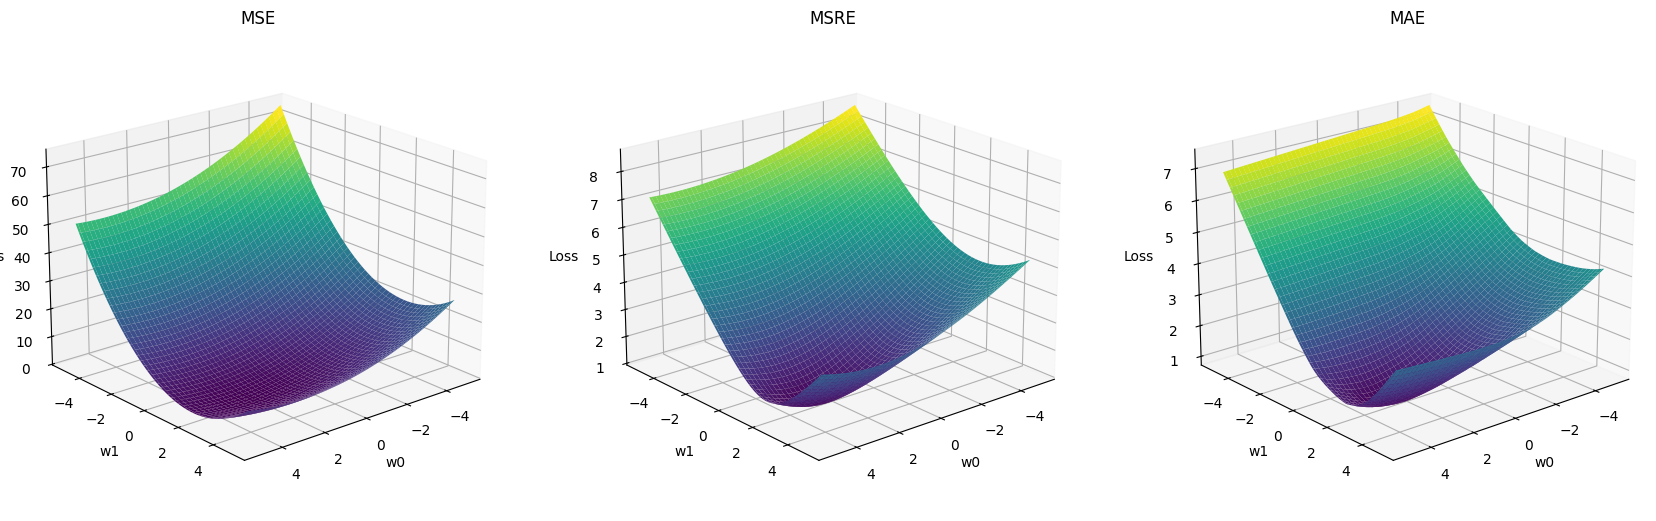

In [4]:
weights = grid_samples()
loss_animator.plot_loss_funcs(
    weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])

In [ ]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()

In [6]:
def optimize_function(fn, optim, optim_args, start_point, num_iter=50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses

In [7]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter=50,
    step_skip=1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(
            loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [8]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad

#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [9]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * \
                    prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [10]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * \
                    prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * \
                    self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [11]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [12]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + \
                    (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [13]:
from functools import partial

points, losses = optimize_function(
    partial(loss_animator.loss_func, loss=mse),
    SGD,
    {'lr': 1e-2},
    start_point=[-4, -4],
    num_iter=100
)

In [14]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        ['Momentum', NAG, {'lr': 1e-1}],
        ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta': 1}],
        ['RMSProp', RMSProp, {'eta': 1}],
    ],
    start_point=[-4, -4],
    num_iter=100
)

  0%|          | 0/5 [00:00<?, ?it/s]

###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [15]:
!wget www.di.ens.fr/~lelarge/MNIST.tar.gz
!tar -zxvf MNIST.tar.gz

zsh:1: command not found: wget
tar: Error opening archive: Failed to open 'MNIST.tar.gz'


In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    '.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=True)

#### Adam

\begin{align*}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta_t &= \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align*}



In [17]:
class Adam(Optimizer):
    def __init__(self, params, epsilon=1e-8, lr=1e-3, beta1=0.9, beta2=0.999):
        super().__init__(params)
        self.epsilon = epsilon
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.t = 0

        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def step(self):
        self.t += 1

        with torch.no_grad():
            for i, p in enumerate(self.params):

                if p.grad is None:
                    continue

                self.m[i] = self.beta1 * self.m[i] + \
                    (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * self.v[i] + \
                    (1 - self.beta2) * p.grad ** 2

                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                p -= self.lr * (m_hat / (torch.sqrt(v_hat) + self.epsilon))

#### AdamW

\begin{align*}
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta_t &= \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_{t-1}
\end{align*}



In [18]:
class AdamW(Optimizer):
    def __init__(self, params, epsilon=1e-8, lr=1e-3, beta1=0.9, beta2=0.999, weight_decay=4e-4):
        super().__init__(params)
        self.epsilon = epsilon
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.t = 0
        self.weight_decay = weight_decay

        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def step(self):
        self.t += 1

        with torch.no_grad():
            for i, p in enumerate(self.params):

                if p.grad is None:
                    continue

                self.m[i] = self.beta1 * self.m[i] + \
                    (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * self.v[i] + \
                    (1 - self.beta2) * p.grad ** 2

                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                p -= self.lr * (m_hat / (torch.sqrt(v_hat) +
                                self.epsilon) + self.weight_decay * p)

In [19]:
# compare_optimizers(
#     loss_animator,
#     mse,
#     [
#         ['Adam', Adam, {'lr': 1e-1, 'beta1': 0.9, 'beta2': 0.999}],
#         ['AdamW', AdamW, {'lr': 1e-1, 'beta1': 0.9, 'beta2': 0.999}]
#     ],
#     start_point=[-4, -3],
#     num_iter=100
# )

In [20]:
class LRScheduler:
    def __init__(self, optimizer: Optimizer):
        self.optimizer = optimizer

    def step(self):
        pass

In [ ]:
class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters
        self.last_epoch = 0
        self.base_lr = self.optimizer.lr

    def step(self):
        if self.last_epoch >= self.total_iters:
            factor = self.end_factor
        else:
            factor = self.start_factor + \
                (self.end_factor - self.start_factor) * \
                (self.last_epoch / self.total_iters)

        self.optimizer.lr = self.base_lr * factor

        self.last_epoch += 1


class CosineAnnealing(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        T_max: int = 20,
        eta_min: float = 0.01
    ):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min
        self.last_epoch = 0
        self.eta_max = self.optimizer.lr

    def step(self):

        lr = self.eta_min + 0.5 * (self.eta_max - self.eta_min) * (1 + torch.cos(
            torch.tensor(self.last_epoch, dtype=torch.float32) * torch.pi / self.T_max))

        self.optimizer.lr = lr.item()

        self.last_epoch += 1

In [22]:
import torch.nn as nn


class Model(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            # (b, 1, 28, 28)
            nn.Conv2d(1, 3, 3),  # (b, 3, 26, 26)
            nn.ReLU(),
            nn.Conv2d(3, 1, 3),  # (b, 1, 24, 24)
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(576, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, X):
        return self.layer(X)

In [23]:
from tqdm import tqdm
import matplotlib.pyplot as plt


def train(my_model, loss_fn, optimizer, schedule=None):
    optimizer_name = type(optimizer).__name__
    schedule_name = type(schedule).__name__

    losses_train = []
    losses_test = []

    for epoch in tqdm(range(10), desc='Epochs'):
        my_model.train()
        loss_train = []
        train_loader_iter = tqdm(
            train_loader, desc=f'Epoch {epoch+1} Train', leave=False)

        for batch_train in train_loader_iter:
            X, y = batch_train[0], batch_train[1]
            y_hat = my_model(X)
            loss = loss_fn(y_hat, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if schedule is not None:
                schedule.step()

            loss_train.append(loss.item())

            train_loader_iter.set_postfix(loss=f'{loss.item():.4f}')

        mean_train_loss = sum(loss_train) / len(loss_train)
        tqdm.write(f'epoch: {epoch + 1}, train_loss={mean_train_loss:.4f}')
        losses_train.append(mean_train_loss)

        my_model.eval()
        loss_test = []
        test_loader_iter = tqdm(
            test_loader, desc=f'Epoch {epoch+1} Test', leave=False)

        with torch.no_grad():
            for batch_test in test_loader_iter:
                X, y = batch_test[0], batch_test[1]
                y_hat = my_model(X)
                loss = loss_fn(y_hat, y)
                loss_test.append(loss.item())

                mean_test_loss = sum(loss_test) / len(loss_test)
                test_loader_iter.set_postfix(loss=f'{mean_test_loss:.4f}')

        losses_test.append(mean_test_loss)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 11), losses_train,
             label=f'Train Loss ({optimizer_name}, with schedule = {schedule_name})')
    plt.plot(range(1, 11), losses_test,
             label=f'Test Loss ({optimizer_name}, with schedule = {schedule_name})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

* 1 ЗАДАНИЕ

Epochs:   0%|          | 0/10 [00:09<?, ?it/s]

epoch: 1, train_loss=0.4601


Epochs:  10%|█         | 1/10 [00:20<01:35, 10.64s/it]

epoch: 2, train_loss=0.1529


Epochs:  20%|██        | 2/10 [00:30<01:23, 10.46s/it]

...

Epochs:  80%|████████  | 8/10 [01:32<00:20, 10.29s/it]

epoch: 9, train_loss=0.0560


Epochs:  90%|█████████ | 9/10 [01:42<00:10, 10.25s/it]

epoch: 10, train_loss=0.0515


Epochs: 100%|██████████| 10/10 [01:43<00:00, 10.39s/it]


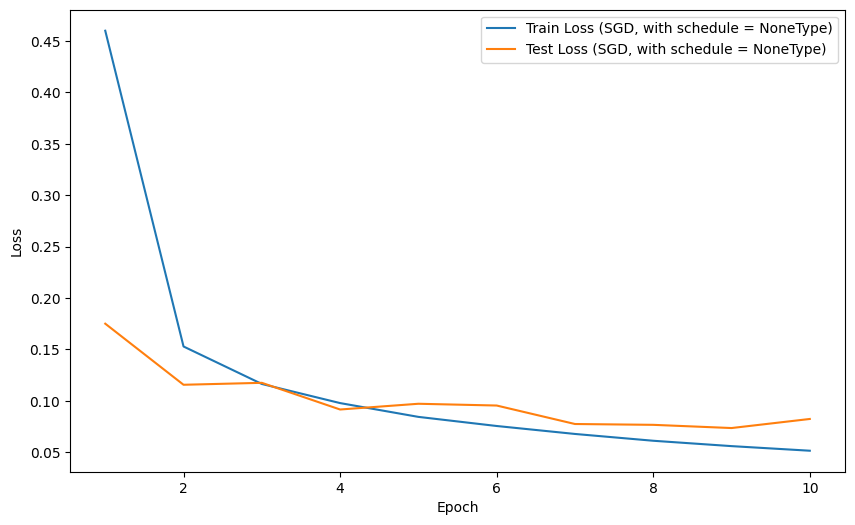

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.3198


Epochs:  10%|█         | 1/10 [00:22<01:48, 12.00s/it]

epoch: 2, train_loss=0.1306


Epochs:  20%|██        | 2/10 [00:34<01:34, 11.84s/it]

...

Epochs:  80%|████████  | 8/10 [01:41<00:22, 11.16s/it]

epoch: 9, train_loss=0.0324


Epochs:  90%|█████████ | 9/10 [01:52<00:11, 11.32s/it]

epoch: 10, train_loss=0.0259


Epochs: 100%|██████████| 10/10 [01:53<00:00, 11.32s/it]


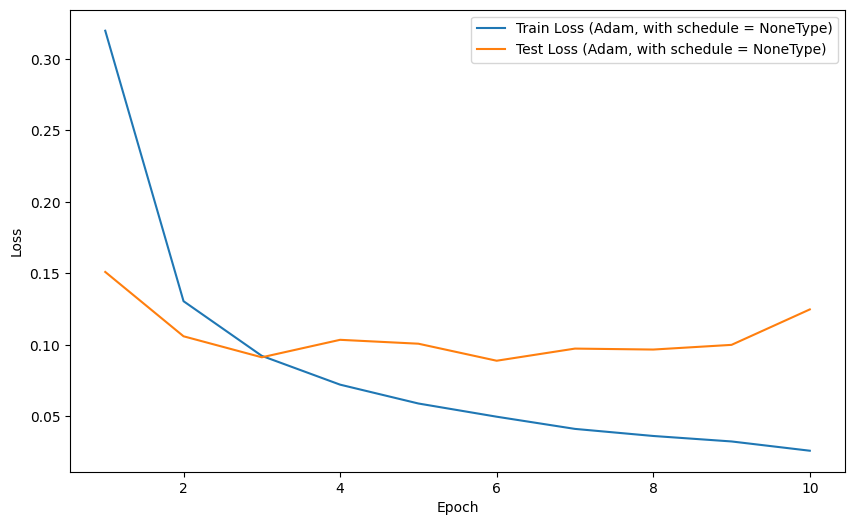

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.3103


Epochs:  10%|█         | 1/10 [00:21<01:41, 11.28s/it]

epoch: 2, train_loss=0.1334


Epochs:  20%|██        | 2/10 [00:34<01:32, 11.57s/it]

...

Epochs:  80%|████████  | 8/10 [01:46<00:23, 11.97s/it]

epoch: 9, train_loss=0.0397


Epochs:  90%|█████████ | 9/10 [01:58<00:11, 11.98s/it]

epoch: 10, train_loss=0.0346


Epochs: 100%|██████████| 10/10 [01:59<00:00, 11.91s/it]


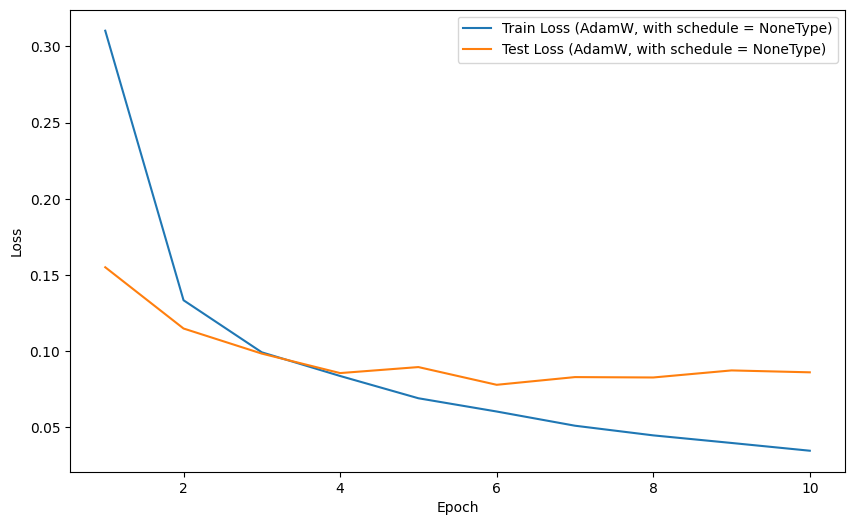

In [24]:
# SGD
sgd_model = Model()
sgd_optimizer = SGD(sgd_model.parameters())

# Adam
adam_model = Model()
adam_optimizer = Adam(adam_model.parameters())

# AdamW
adamw_model = Model()
adamw_optimizer = AdamW(adamw_model.parameters())

models = [sgd_model, adam_model, adamw_model]
optimizers = [sgd_optimizer, adam_optimizer, adamw_optimizer]

for model, optimizer in zip(models, optimizers):
    train(model, nn.CrossEntropyLoss(), optimizer)

* 2 ЗАДАНИЕ

Epochs:   0%|          | 0/10 [00:09<?, ?it/s]

epoch: 1, train_loss=0.4421


Epochs:  10%|█         | 1/10 [00:20<01:38, 10.95s/it]

epoch: 2, train_loss=0.1535


Epochs:  20%|██        | 2/10 [00:31<01:27, 10.91s/it]

...

Epochs:  80%|████████  | 8/10 [01:37<00:21, 10.88s/it]

epoch: 9, train_loss=0.0543


Epochs:  90%|█████████ | 9/10 [01:47<00:10, 10.88s/it]

epoch: 10, train_loss=0.0501


Epochs: 100%|██████████| 10/10 [01:48<00:00, 10.89s/it]


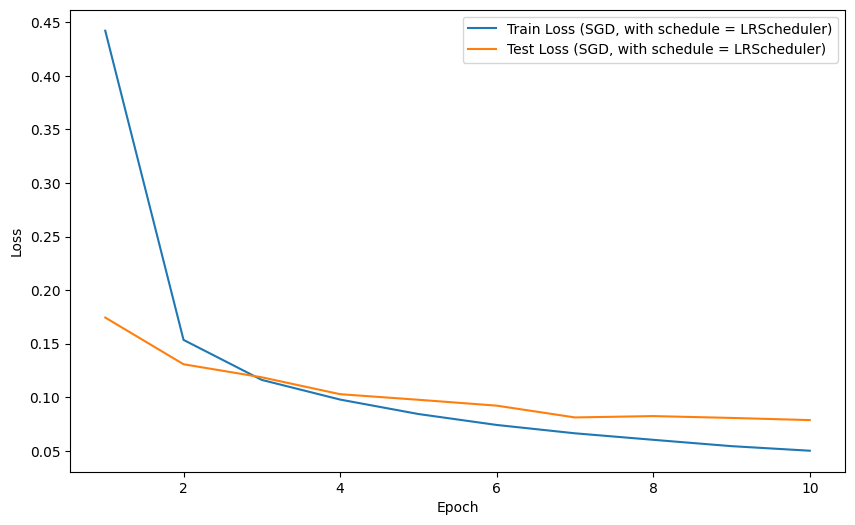

Epochs:   0%|          | 0/10 [00:09<?, ?it/s]

epoch: 1, train_loss=0.0466


Epochs:  10%|█         | 1/10 [00:20<01:37, 10.85s/it]

epoch: 2, train_loss=0.0430


Epochs:  20%|██        | 2/10 [00:31<01:26, 10.83s/it]

...

Epochs:  80%|████████  | 8/10 [01:36<00:21, 10.84s/it]

epoch: 9, train_loss=0.0259


Epochs:  90%|█████████ | 9/10 [01:47<00:10, 10.82s/it]

epoch: 10, train_loss=0.0228


Epochs: 100%|██████████| 10/10 [01:48<00:00, 10.85s/it]


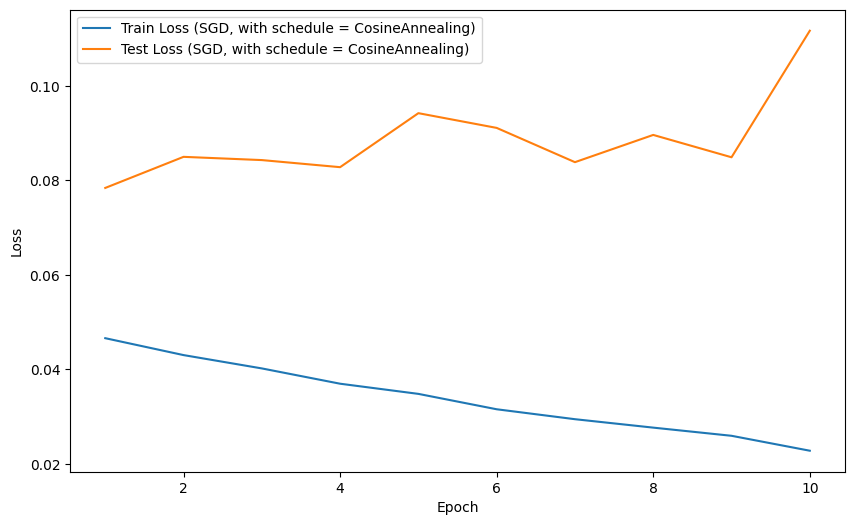

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.3366


Epochs:  10%|█         | 1/10 [00:22<01:44, 11.64s/it]

epoch: 2, train_loss=0.1288


Epochs:  20%|██        | 2/10 [00:33<01:34, 11.77s/it]

...

Epochs:  80%|████████  | 8/10 [01:40<00:22, 11.23s/it]

epoch: 9, train_loss=0.0336


Epochs:  90%|█████████ | 9/10 [01:52<00:11, 11.33s/it]

epoch: 10, train_loss=0.0299


Epochs: 100%|██████████| 10/10 [01:53<00:00, 11.34s/it]


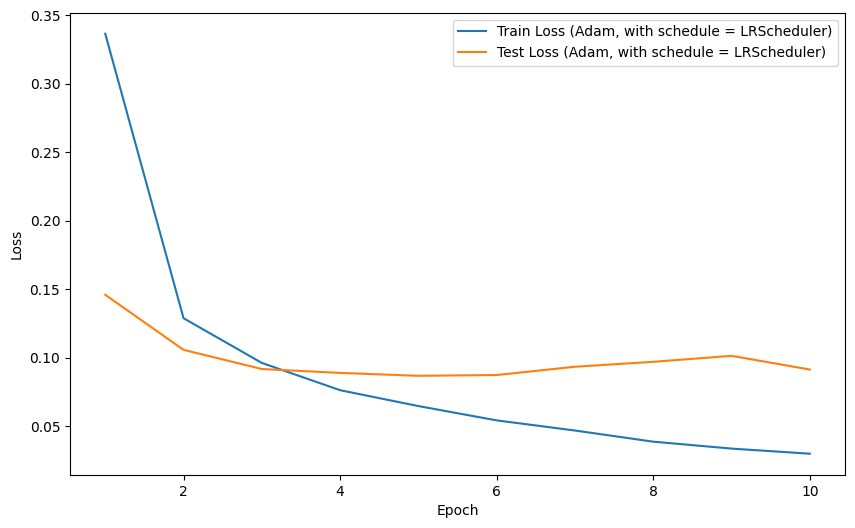

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.1292


Epochs:  10%|█         | 1/10 [00:22<01:44, 11.60s/it]

epoch: 2, train_loss=0.0911


Epochs:  20%|██        | 2/10 [00:33<01:33, 11.66s/it]

...

Epochs:  80%|████████  | 8/10 [01:43<00:23, 11.53s/it]

epoch: 9, train_loss=0.0459


Epochs:  90%|█████████ | 9/10 [01:54<00:11, 11.52s/it]

epoch: 10, train_loss=0.0404


Epochs: 100%|██████████| 10/10 [01:55<00:00, 11.57s/it]


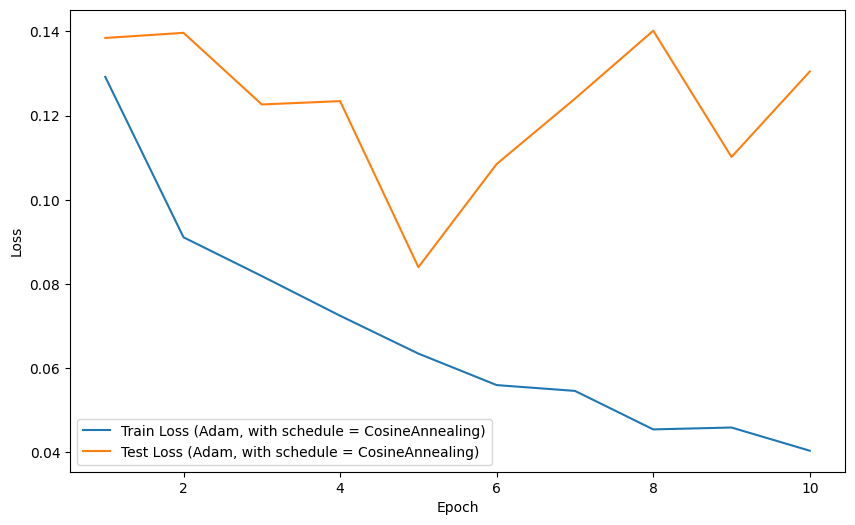

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.2866


Epochs:  10%|█         | 1/10 [00:22<01:45, 11.68s/it]

epoch: 2, train_loss=0.1281


Epochs:  20%|██        | 2/10 [00:34<01:33, 11.64s/it]

...

Epochs:  80%|████████  | 8/10 [01:43<00:23, 11.58s/it]

epoch: 9, train_loss=0.0342


Epochs:  90%|█████████ | 9/10 [01:55<00:11, 11.60s/it]

epoch: 10, train_loss=0.0279


Epochs: 100%|██████████| 10/10 [01:56<00:00, 11.61s/it]


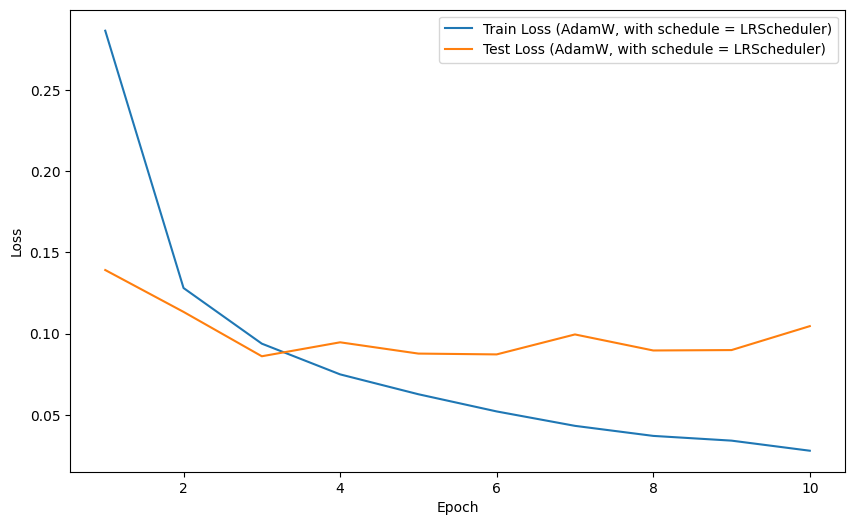

Epochs:   0%|          | 0/10 [00:10<?, ?it/s]

epoch: 1, train_loss=0.1298


Epochs:  10%|█         | 1/10 [00:22<01:46, 11.81s/it]

epoch: 2, train_loss=0.0922


Epochs:  20%|██        | 2/10 [00:33<01:31, 11.49s/it]

...

Epochs:  80%|████████  | 8/10 [01:42<00:22, 11.24s/it]

epoch: 9, train_loss=0.0426


Epochs:  90%|█████████ | 9/10 [01:53<00:11, 11.62s/it]

epoch: 10, train_loss=0.0367


Epochs: 100%|██████████| 10/10 [01:54<00:00, 11.45s/it]


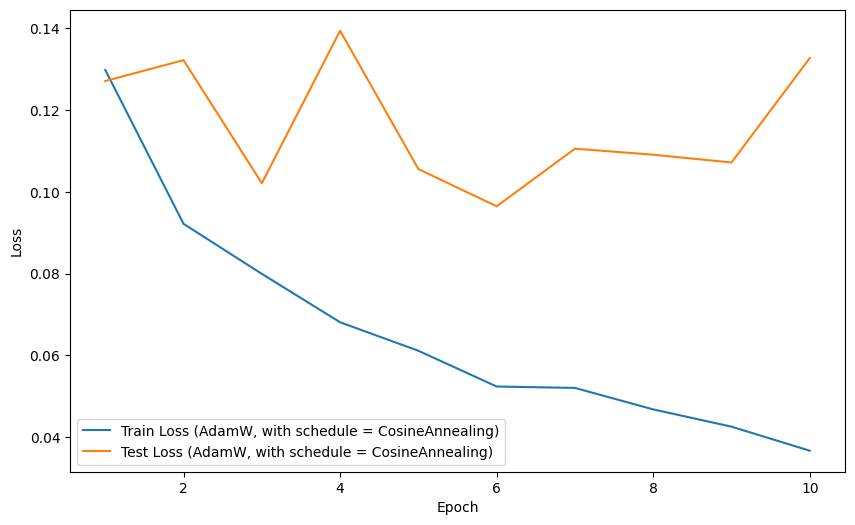

In [40]:
# SGD
sgd_model = Model()
sgd_optimizer = SGD(sgd_model.parameters())

# Adam
adam_model = Model()
adam_optimizer = Adam(adam_model.parameters())

# AdamW
adamw_model = Model()
adamw_optimizer = AdamW(adamw_model.parameters())

models = [sgd_model, adam_model, adamw_model]
optimizers = [sgd_optimizer, adam_optimizer, adamw_optimizer]

for model, optimizer in zip(models, optimizers):
    scheduler_linear = LRScheduler(optimizer)
    scheduler_cos = CosineAnnealing(optimizer)

    train(model, nn.CrossEntropyLoss(), optimizer, scheduler_linear)

    train(model, nn.CrossEntropyLoss(), optimizer, scheduler_cos)

#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here